# 🎬 Netflix Content Data Analysis & Visualization
### A Visual Story of What Netflix Streams, Where, and How It Has Evolved

**Objective:** Transform the raw Netflix catalog dataset into clear, decision-ready visuals — revealing content mix, growth trends, geographic reach, ratings, genres, and runtime patterns.

**Tools:** Python, Pandas, Matplotlib, Seaborn

**Dataset:** `Netflix_Dataset.csv` — 7,789 titles (Movies & TV Shows) with metadata on director, cast, country, release date, rating, duration, genre, and description.

---


## 1. Setup & Styling
We start by importing our libraries and setting a consistent, presentation-ready visual theme used throughout this notebook.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

# --- Visual theme (applied consistently across every chart) ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "#222222",
    "text.color": "#222222",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "font.size": 11,
    "figure.dpi": 110,
})

# Netflix-inspired accent palette
NETFLIX_RED   = "#E50914"
NETFLIX_DARK  = "#221F1F"
ACCENT_GREY   = "#B3B3B3"
PALETTE       = ["#E50914", "#221F1F", "#B3B3B3", "#F5A623", "#564D4D", "#831010", "#8C8C8C"]
sns.set_palette(PALETTE)

pd.set_option("display.max_columns", None)


## 2. Load & Inspect the Data

In [2]:

df = pd.read_csv("Netflix_Dataset.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 7,789 rows x 11 columns


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [3]:

print("Missing values per column:")
print(df.isna().sum())
print()
print("Content type breakdown:")
print(df['Category'].value_counts())


Missing values per column:
Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64

Content type breakdown:
Category
Movie      5379
TV Show    2410
Name: count, dtype: int64


## 3. Data Cleaning & Feature Engineering
We prepare the data for visualization:
- Parse `Release_Date` into a proper datetime and extract `Release_Year` / `Release_Month`
- Split `Duration` into a numeric value for **Movies** (minutes) and **TV Shows** (seasons)
- Explode the multi-label `Type` (genre) field into individual genres
- Explode the multi-country field for country-level analysis
- Fill missing categorical values with `"Unknown"` for clean plotting

In [4]:

df_clean = df.copy()

# Parse dates
df_clean['Release_Date'] = pd.to_datetime(df_clean['Release_Date'], errors='coerce')
df_clean['Release_Year'] = df_clean['Release_Date'].dt.year
df_clean['Release_Month'] = df_clean['Release_Date'].dt.month_name()

# Split duration into numeric minutes (movies) / seasons (TV shows)
def parse_minutes(row):
    if row['Category'] == 'Movie' and isinstance(row['Duration'], str) and 'min' in row['Duration']:
        return int(row['Duration'].replace(' min', '').strip())
    return np.nan

def parse_seasons(row):
    if row['Category'] == 'TV Show' and isinstance(row['Duration'], str):
        return int(row['Duration'].split(' ')[0])
    return np.nan

df_clean['Duration_Minutes'] = df_clean.apply(parse_minutes, axis=1)
df_clean['Num_Seasons'] = df_clean.apply(parse_seasons, axis=1)

# Fill key categorical NAs for cleaner grouping
df_clean['Country'] = df_clean['Country'].fillna('Unknown')
df_clean['Rating'] = df_clean['Rating'].fillna('Not Rated')
df_clean['Director'] = df_clean['Director'].fillna('Unknown')

# Primary country only (first listed) for country-level breakdowns
df_clean['Primary_Country'] = df_clean['Country'].apply(lambda x: x.split(',')[0].strip())

print("Cleaned dataset ready:", df_clean.shape)
df_clean[['Title','Category','Release_Year','Duration_Minutes','Num_Seasons','Primary_Country']].head()


Cleaned dataset ready: (7789, 16)


,Title,Category,Release_Year,Duration_Minutes,Num_Seasons,Primary_Country
0,3%,TV Show,2020.0,NaN,4.0,Brazil
1,07:19,Movie,2016.0,93.0,NaN,Mexico
2,23:59,Movie,2018.0,78.0,NaN,Singapore
3,9,Movie,2017.0,80.0,NaN,United States
4,21,Movie,2020.0,123.0,NaN,United States


## 4. Content Mix: Movies vs. TV Shows
**Insight goal:** How does Netflix's catalog split between Movies and TV Shows?

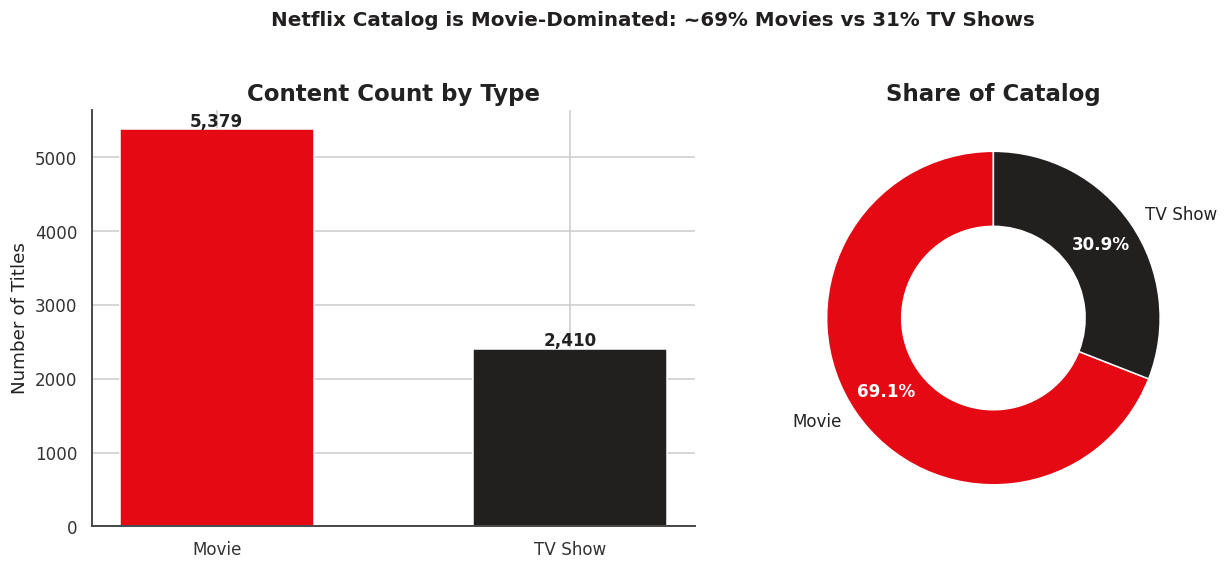

In [5]:

type_counts = df_clean['Category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(type_counts.index, type_counts.values, color=[NETFLIX_RED, NETFLIX_DARK], width=0.55)
axes[0].set_title("Content Count by Type")
axes[0].set_ylabel("Number of Titles")
for b in bars:
    h = b.get_height()
    axes[0].text(b.get_x() + b.get_width()/2, h + 40, f"{h:,}", ha='center', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
    startangle=90, colors=[NETFLIX_RED, NETFLIX_DARK],
    wedgeprops=dict(width=0.45, edgecolor='white'), pctdistance=0.78
)
for at in autotexts:
    at.set_color('white'); at.set_fontweight('bold')
axes[1].set_title("Share of Catalog")

plt.suptitle("Netflix Catalog is Movie-Dominated: ~69% Movies vs 31% TV Shows", fontsize=13, y=1.03, color=NETFLIX_DARK, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Content Growth Over Time
**Insight goal:** How has Netflix's content library grown year over year, and how has the Movie/TV Show mix shifted?

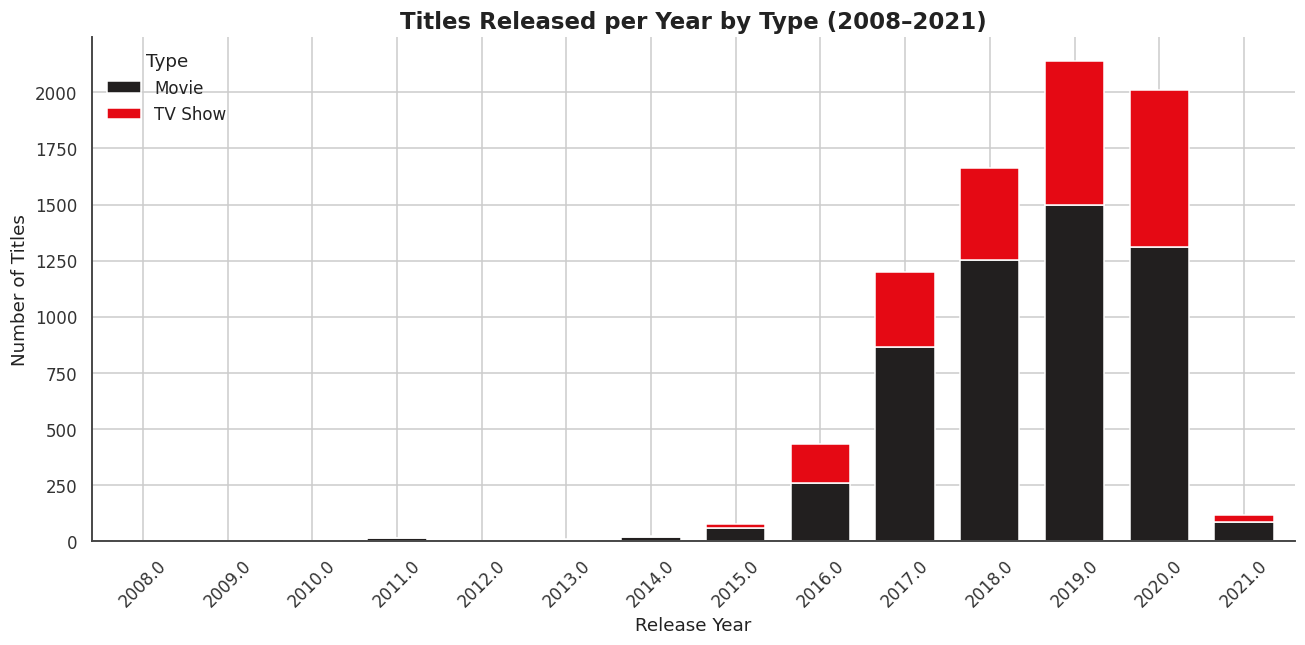

Peak content release year: 2019 with 2,137 titles


In [6]:

yearly = df_clean.dropna(subset=['Release_Year'])
yearly = yearly[yearly['Release_Year'] >= 2008]  # focus on the streaming era
yearly_counts = yearly.groupby(['Release_Year','Category']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
yearly_counts.plot(kind='bar', stacked=True, ax=ax, color=[NETFLIX_DARK, NETFLIX_RED], width=0.7)
ax.set_title("Titles Released per Year by Type (2008–2021)")
ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Titles")
ax.legend(title="Type", frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

peak_year = yearly_counts.sum(axis=1).idxmax()
print(f"Peak content release year: {int(peak_year)} with {yearly_counts.sum(axis=1).max():,} titles")


## 6. Where Does Netflix's Content Come From?
**Insight goal:** Identify the top content-producing countries to understand Netflix's geographic footprint.

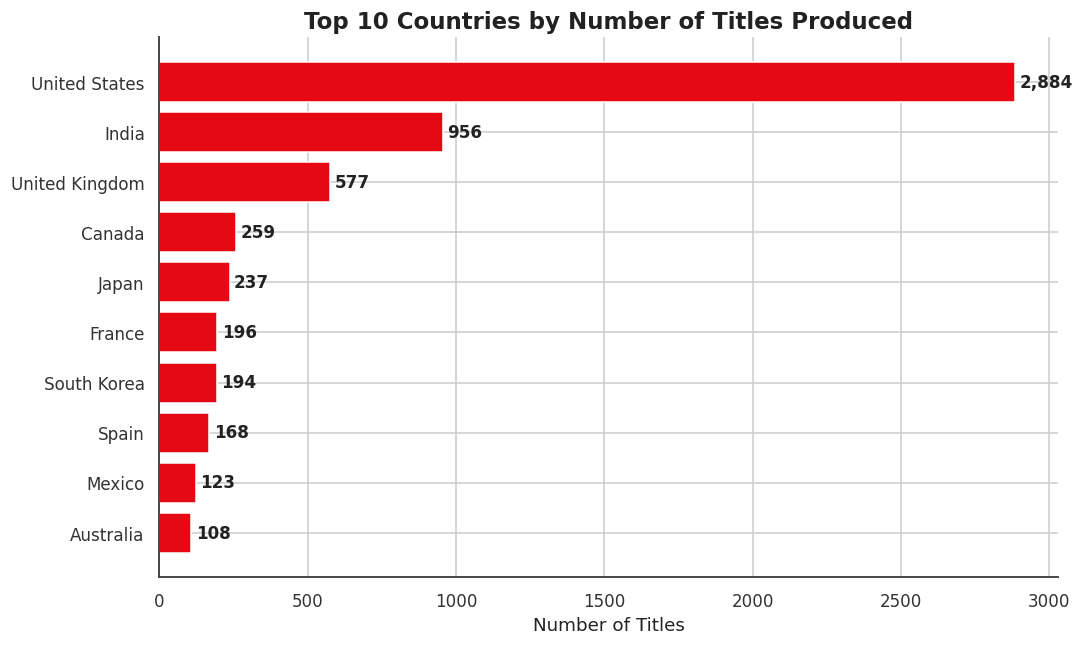

The United States alone accounts for 2,884 titles, 37.0% of the full catalog.


In [7]:

top_countries = (
    df_clean[df_clean['Primary_Country'] != 'Unknown']['Primary_Country']
    .value_counts()
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_countries.index, top_countries.values, color=NETFLIX_RED)
ax.set_title("Top 10 Countries by Number of Titles Produced")
ax.set_xlabel("Number of Titles")
ax.spines[['top','right']].set_visible(False)
for b in bars:
    w = b.get_width()
    ax.text(w + 15, b.get_y() + b.get_height()/2, f"{int(w):,}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"The United States alone accounts for {top_countries.iloc[-1]:,} titles, "
      f"{top_countries.iloc[-1] / len(df_clean) * 100:.1f}% of the full catalog.")


## 7. Content Ratings Distribution
**Insight goal:** What audience maturity levels dominate the catalog — is Netflix's library more adult-oriented or family-friendly?

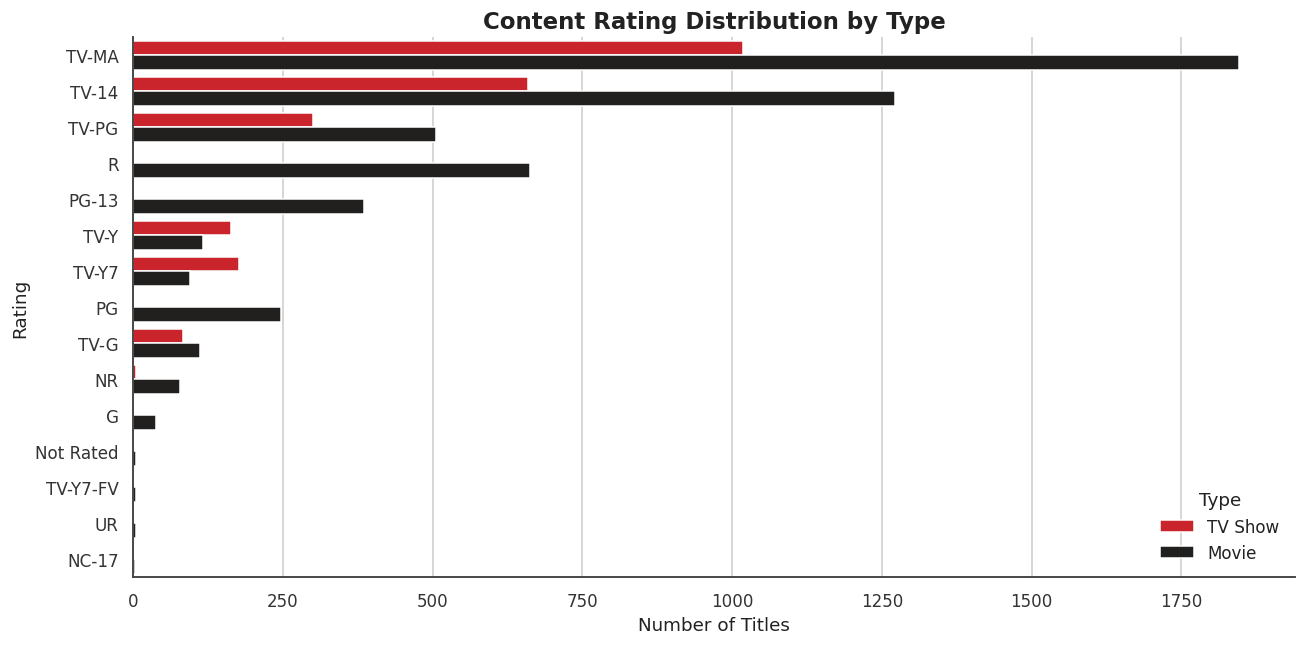

Mature-rated content (TV-MA, R, NC-17): 3,533 titles (45.4% of catalog)


In [8]:

rating_order = df_clean['Rating'].value_counts().index

fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df_clean, y='Rating', order=rating_order, hue='Category',
              palette=[NETFLIX_RED, NETFLIX_DARK], ax=ax)
ax.set_title("Content Rating Distribution by Type")
ax.set_xlabel("Number of Titles")
ax.set_ylabel("Rating")
ax.legend(title="Type", frameon=False, loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

mature = df_clean['Rating'].isin(['TV-MA','R','NC-17']).sum()
print(f"Mature-rated content (TV-MA, R, NC-17): {mature:,} titles ({mature/len(df_clean)*100:.1f}% of catalog)")


## 8. Most Popular Genres
**Insight goal:** The `Type` column contains multiple comma-separated genres per title. We explode this to find the true genre leaders.

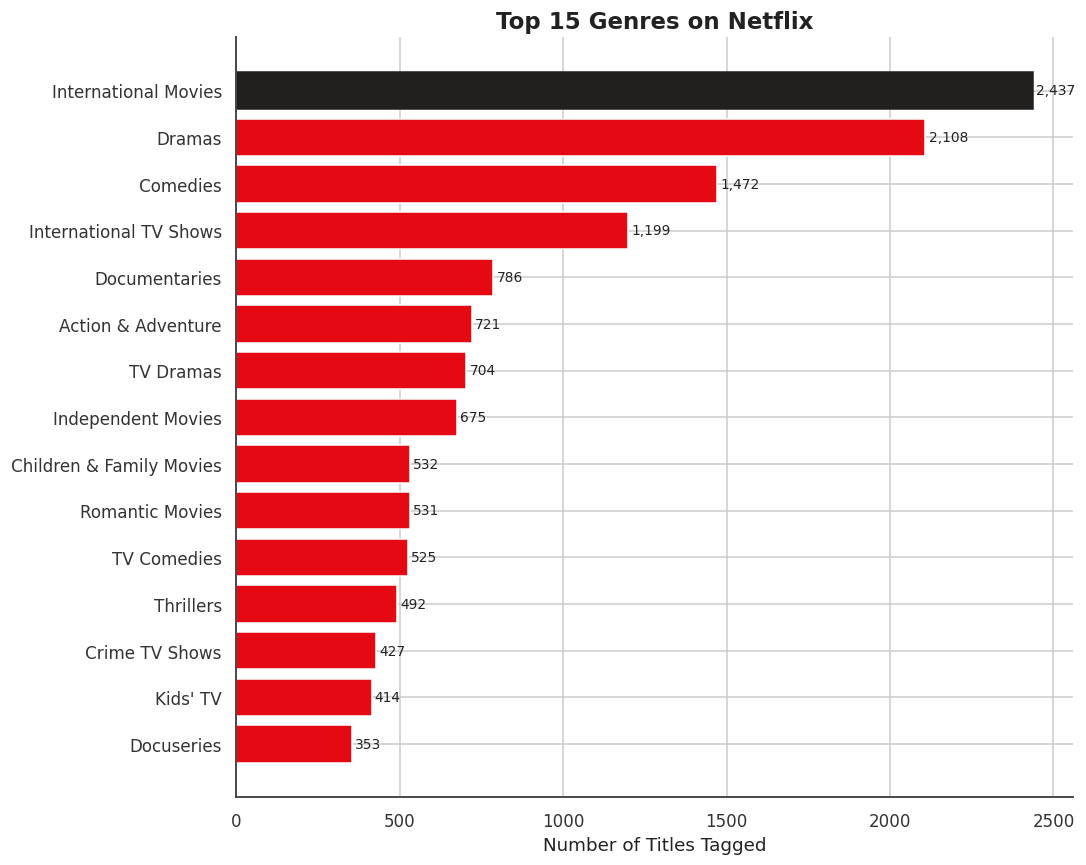

In [9]:

genre_series = df_clean['Type'].dropna().str.split(', ').explode()
top_genres = genre_series.value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top_genres.index, top_genres.values, color=PALETTE[0])
# gradient-like emphasis on top genre
bars[-1].set_color(NETFLIX_DARK)
ax.set_title("Top 15 Genres on Netflix")
ax.set_xlabel("Number of Titles Tagged")
ax.spines[['top','right']].set_visible(False)
for b in bars:
    w = b.get_width()
    ax.text(w + 10, b.get_y() + b.get_height()/2, f"{int(w):,}", va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 9. Movie Duration Distribution
**Insight goal:** What's the typical runtime of a Netflix movie, and how much variation is there?

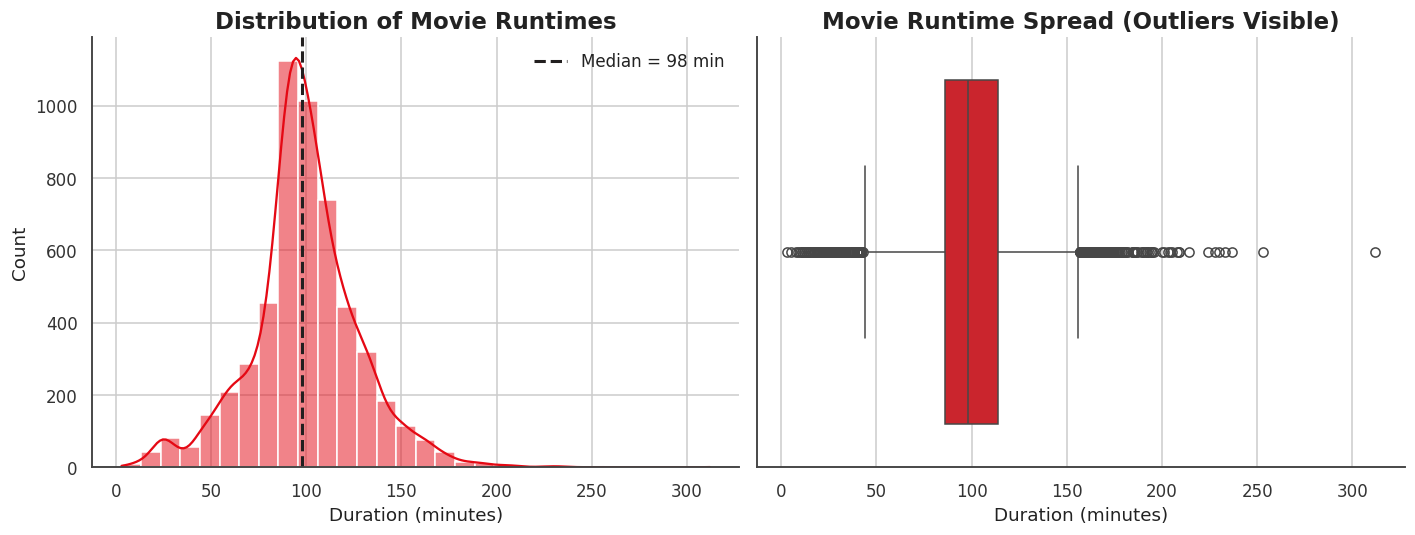

count    5379.0
mean       99.3
std        28.5
min         3.0
25%        86.0
50%        98.0
75%       114.0
max       312.0
Name: Duration_Minutes, dtype: float64


In [10]:

movies = df_clean[df_clean['Category'] == 'Movie'].dropna(subset=['Duration_Minutes'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(movies['Duration_Minutes'], bins=30, color=NETFLIX_RED, ax=axes[0], kde=True)
axes[0].axvline(movies['Duration_Minutes'].median(), color=NETFLIX_DARK, linestyle='--', linewidth=2,
                label=f"Median = {movies['Duration_Minutes'].median():.0f} min")
axes[0].set_title("Distribution of Movie Runtimes")
axes[0].set_xlabel("Duration (minutes)")
axes[0].legend(frameon=False)
axes[0].spines[['top','right']].set_visible(False)

sns.boxplot(x=movies['Duration_Minutes'], ax=axes[1], color=NETFLIX_RED)
axes[1].set_title("Movie Runtime Spread (Outliers Visible)")
axes[1].set_xlabel("Duration (minutes)")
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print(movies['Duration_Minutes'].describe().round(1))


## 10. TV Show Season Counts
**Insight goal:** Most TV shows on Netflix — are they short limited series or long-running shows?

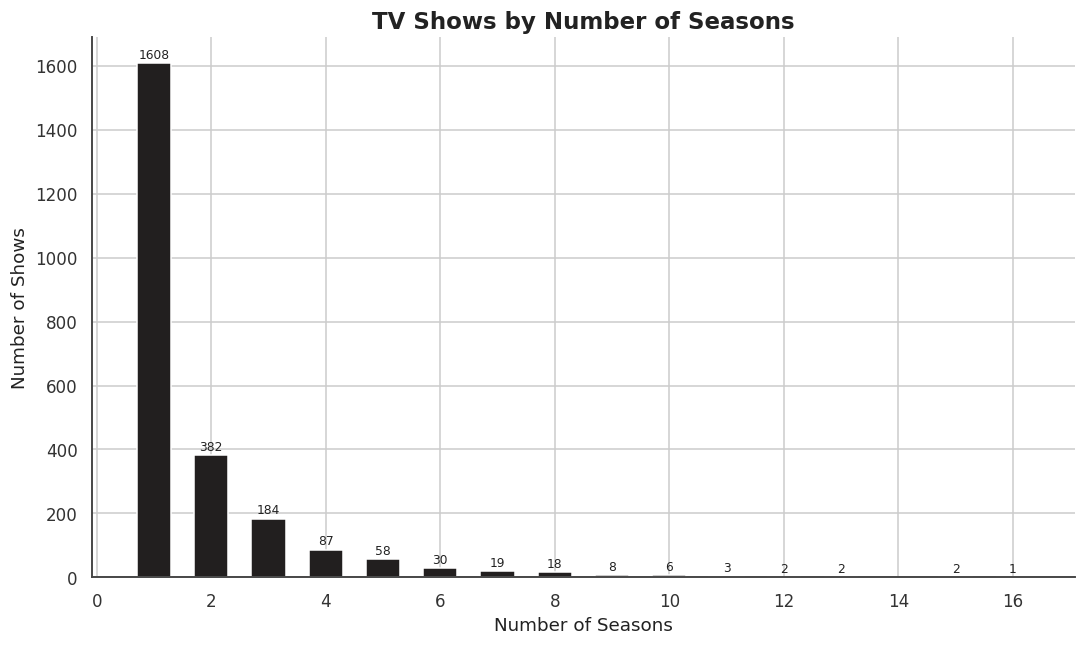

66.7% of TV shows on Netflix have only 1 season — favoring limited series over long runs.


In [11]:

tv = df_clean[df_clean['Category'] == 'TV Show'].dropna(subset=['Num_Seasons'])
season_counts = tv['Num_Seasons'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(season_counts.index.astype(int), season_counts.values, color=NETFLIX_DARK, width=0.6)
ax.set_title("TV Shows by Number of Seasons")
ax.set_xlabel("Number of Seasons")
ax.set_ylabel("Number of Shows")
ax.spines[['top','right']].set_visible(False)
for b in bars:
    h = b.get_height()
    if h > 0:
        ax.text(b.get_x() + b.get_width()/2, h + 15, f"{int(h)}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

one_season_pct = (tv['Num_Seasons'] == 1).mean() * 100
print(f"{one_season_pct:.1f}% of TV shows on Netflix have only 1 season — favoring limited series over long runs.")


## 11. Content Addition Heatmap: Year × Month
**Insight goal:** Does Netflix release content evenly throughout the year, or are there seasonal patterns?

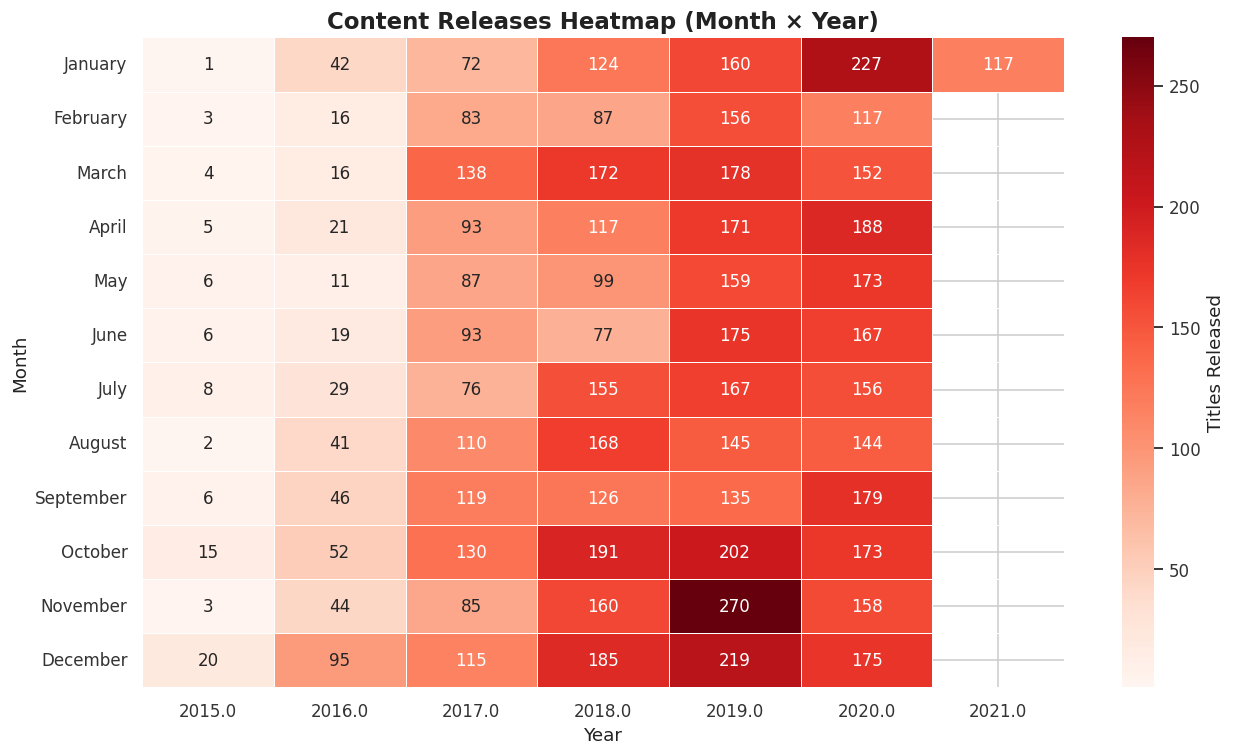

In [12]:

heat_df = df_clean.dropna(subset=['Release_Date'])
heat_df = heat_df[heat_df['Release_Year'] >= 2015]
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

pivot = heat_df.pivot_table(index='Release_Month', columns='Release_Year',
                             values='Show_Id', aggfunc='count').reindex(month_order)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, cmap='Reds', annot=True, fmt='.0f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Titles Released'}, ax=ax)
ax.set_title("Content Releases Heatmap (Month × Year)")
ax.set_xlabel("Year")
ax.set_ylabel("Month")
plt.tight_layout()
plt.show()


## 12. Top Directors on Netflix
**Insight goal:** Which directors have the most titles in the Netflix catalog?

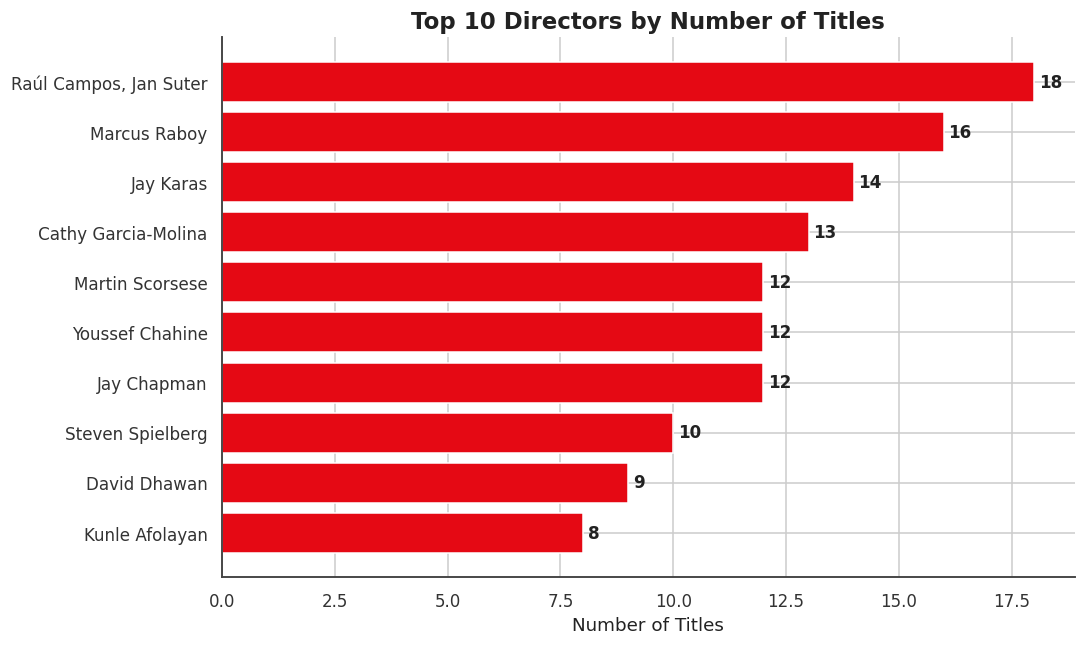

In [13]:

top_directors = (
    df_clean[df_clean['Director'] != 'Unknown']['Director']
    .value_counts()
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_directors.index, top_directors.values, color=NETFLIX_RED)
ax.set_title("Top 10 Directors by Number of Titles")
ax.set_xlabel("Number of Titles")
ax.spines[['top','right']].set_visible(False)
for b in bars:
    w = b.get_width()
    ax.text(w + 0.1, b.get_y() + b.get_height()/2, f"{int(w)}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 13. Executive Summary Dashboard
A single-view dashboard combining the most decision-relevant visuals for a quick executive read.

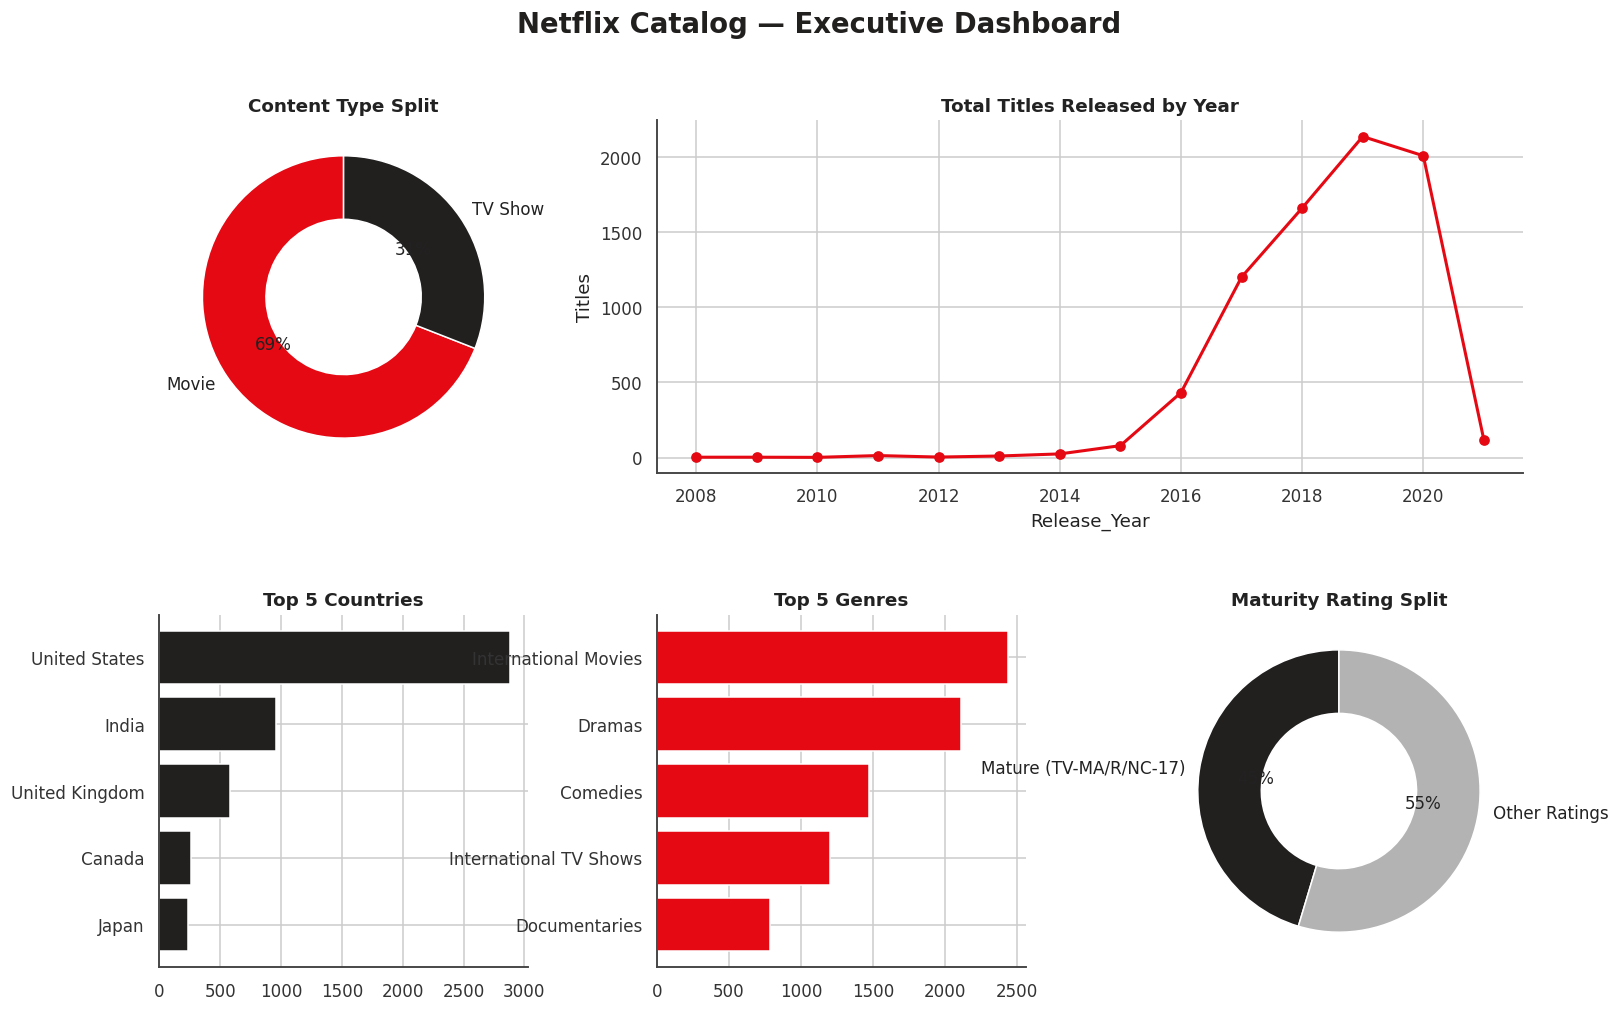

In [14]:

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# 1. Movie vs TV Show
ax1 = fig.add_subplot(gs[0, 0])
ax1.pie(type_counts.values, labels=type_counts.index, autopct='%1.0f%%', startangle=90,
        colors=[NETFLIX_RED, NETFLIX_DARK], wedgeprops=dict(width=0.45, edgecolor='white'))
ax1.set_title("Content Type Split", fontsize=12)

# 2. Yearly trend
ax2 = fig.add_subplot(gs[0, 1:])
yearly_counts.sum(axis=1).plot(ax=ax2, color=NETFLIX_RED, marker='o', linewidth=2)
ax2.set_title("Total Titles Released by Year", fontsize=12)
ax2.set_ylabel("Titles")
ax2.spines[['top','right']].set_visible(False)

# 3. Top countries
ax3 = fig.add_subplot(gs[1, 0])
top5_c = top_countries.tail(5)
ax3.barh(top5_c.index, top5_c.values, color=NETFLIX_DARK)
ax3.set_title("Top 5 Countries", fontsize=12)
ax3.spines[['top','right']].set_visible(False)

# 4. Top genres
ax4 = fig.add_subplot(gs[1, 1])
top5_g = top_genres.tail(5)
ax4.barh(top5_g.index, top5_g.values, color=NETFLIX_RED)
ax4.set_title("Top 5 Genres", fontsize=12)
ax4.spines[['top','right']].set_visible(False)

# 5. Rating split (mature vs family-friendly, simplified)
ax5 = fig.add_subplot(gs[1, 2])
mature_labels = ['Mature (TV-MA/R/NC-17)', 'Other Ratings']
mature_vals = [mature, len(df_clean) - mature]
ax5.pie(mature_vals, labels=mature_labels, autopct='%1.0f%%', startangle=90,
        colors=[NETFLIX_DARK, ACCENT_GREY], wedgeprops=dict(width=0.45, edgecolor='white'))
ax5.set_title("Maturity Rating Split", fontsize=12)

fig.suptitle("Netflix Catalog — Executive Dashboard", fontsize=18, fontweight='bold', color=NETFLIX_DARK)
plt.savefig('netflix_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Key Takeaways & Recommendations

1. **Movies dominate the catalog (~69%)** — TV Shows are a growing but still minority share. If subscriber retention benefits more from binge-worthy series, there may be room to grow the TV Show pipeline further.
2. **Content additions accelerated sharply post-2016**, peaking around 2019–2020, reflecting Netflix's global content investment push before plateauing — useful context for forecasting future acquisition budgets.
3. **The United States, India, and the UK lead content production** — confirming Netflix's core content hubs, while highlighting where international originals could expand reach.
4. **TV-MA and TV-14 dominate ratings**, signaling a primarily adult/teen-oriented catalog — family (`G`, `TV-Y`) content is comparatively under-represented, a potential gap or intentional positioning.
5. **Dramas, Comedies, and International titles are the most common genres**, indicating core viewer demand areas.
6. **The majority of TV shows have only 1 season**, suggesting Netflix favors limited series and frequent new launches over long-running renewals.
7. **Movie runtimes cluster tightly around 90–100 minutes**, matching standard theatrical runtime conventions.

*This notebook can be extended with sentiment analysis on descriptions, recommendation-engine prototyping, or a Plotly/Dash interactive dashboard for stakeholder-facing delivery.*
